In [1]:
import torch
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
names = open('names.txt','r').read().split()
names

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [5]:
len(names)

32033

In [3]:
chars = sorted(list(set(''.join(names))))
chars.append('.')
print(chars)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '.']


In [4]:
itos = {i:s for i,s in zip(range(1,27),chars)}
itos[0] = "."
itos = dict(sorted(itos.items()))
itos

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [5]:
stoi = {s:i for i,s in itos.items()}
stoi

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

block_size = 3
def build_dataset(names):
  X = []
  Y = []
  for w in names:
      context = [0]*block_size
      for ch in w+".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context),">>>", itos[ix])
        context = context[1:]+[ix]
  X = torch.tensor(X,device=device)
  Y = torch.tensor(Y,device=device)
  return X,Y
import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))
Xtr,Ytr = build_dataset(names[:n1])
Xdev,Ydev = build_dataset(names[n1:n2])
Xte,Yte = build_dataset(names[n2:])

Streaming output truncated to the last 5000 lines.
..a >>> n
.an >>> a
ana >>> i
nai >>> k
aik >>> a
ika >>> .
... >>> k
..k >>> y
.ky >>> l
kyl >>> o
ylo >>> .
... >>> k
..k >>> e
.ke >>> s
kes >>> h
esh >>> u
shu >>> n
hun >>> .
... >>> b
..b >>> r
.br >>> e
bre >>> y
rey >>> a
eya >>> h
yah >>> .
... >>> f
..f >>> a
.fa >>> r
far >>> i
ari >>> d
rid >>> a
ida >>> .
... >>> k
..k >>> a
.ka >>> t
kat >>> a
ata >>> r
tar >>> y
ary >>> n
ryn >>> a
yna >>> .
... >>> t
..t >>> e
.te >>> g
teg >>> a
ega >>> n
gan >>> .
... >>> f
..f >>> a
.fa >>> y
fay >>> g
ayg >>> a
yga >>> .
... >>> n
..n >>> i
.ni >>> a
nia >>> y
iay >>> l
ayl >>> a
yla >>> .
... >>> h
..h >>> a
.ha >>> a
haa >>> r
aar >>> i
ari >>> s
ris >>> .
... >>> i
..i >>> k
.ik >>> t
ikt >>> a
kta >>> n
tan >>> .
... >>> y
..y >>> u
.yu >>> x
yux >>> i
uxi >>> n
xin >>> .
... >>> e
..e >>> l
.el >>> l
ell >>> i
lli >>> c
lic >>> e
ice >>> .
... >>> c
..c >>> a
.ca >>> r
car >>> s
ars >>> y
rsy >>> n
syn >>> .
... >>> e
..e >>> l

In [ ]:
C = torch.randn((27,2))
C

tensor([[-0.1450,  0.9447],
        [-0.7001,  0.7476],
        [-0.7475, -1.1681],
        [ 0.9777,  0.2846],
        [ 0.1179, -0.4755],
        [-0.1188,  0.8453],
        [ 0.7063,  0.0261],
        [ 0.6811,  1.4683],
        [ 0.6531,  0.3028],
        [-1.2232, -1.9589],
        [-0.4466, -0.3943],
        [-1.6582, -1.3166],
        [ 1.8119, -0.9849],
        [-0.0780,  0.2241],
        [ 0.8158, -0.4669],
        [ 0.0859,  0.2469],
        [ 0.8089, -1.7989],
        [ 1.2139,  0.1771],
        [ 0.8529,  2.6386],
        [-1.5535, -0.9489],
        [-0.6265,  0.3839],
        [-1.2180, -1.4000],
        [-1.0824, -0.0918],
        [-0.4717,  0.5483],
        [ 0.5138, -0.5392],
        [ 0.7833, -0.1781],
        [ 1.3884, -0.4032]])

In [ ]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [ ]:
emb = C[X]
emb

tensor([[[ 0.4445, -0.8394],
         [ 0.4445, -0.8394],
         [ 0.4445, -0.8394]],

        [[ 0.4445, -0.8394],
         [ 0.4445, -0.8394],
         [-2.1434,  0.8913]],

        [[ 0.4445, -0.8394],
         [-2.1434,  0.8913],
         [-0.6837,  1.1155]],

        ...,

        [[ 1.4984, -0.6430],
         [ 1.4984, -0.6430],
         [-0.7369, -0.5756]],

        [[ 1.4984, -0.6430],
         [-0.7369, -0.5756],
         [ 1.4984, -0.6430]],

        [[-0.7369, -0.5756],
         [ 1.4984, -0.6430],
         [ 1.8468,  0.3998]]])

In [ ]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [ ]:
emb

tensor([[[ 0.4445, -0.8394],
         [ 0.4445, -0.8394],
         [ 0.4445, -0.8394]],

        [[ 0.4445, -0.8394],
         [ 0.4445, -0.8394],
         [-2.1434,  0.8913]],

        [[ 0.4445, -0.8394],
         [-2.1434,  0.8913],
         [-0.6837,  1.1155]],

        ...,

        [[ 1.4984, -0.6430],
         [ 1.4984, -0.6430],
         [-0.7369, -0.5756]],

        [[ 1.4984, -0.6430],
         [-0.7369, -0.5756],
         [ 1.4984, -0.6430]],

        [[-0.7369, -0.5756],
         [ 1.4984, -0.6430],
         [ 1.8468,  0.3998]]])

In [ ]:
emb.view((-1,6))

tensor([[ 0.4445, -0.8394,  0.4445, -0.8394,  0.4445, -0.8394],
        [ 0.4445, -0.8394,  0.4445, -0.8394, -2.1434,  0.8913],
        [ 0.4445, -0.8394, -2.1434,  0.8913, -0.6837,  1.1155],
        ...,
        [ 1.4984, -0.6430,  1.4984, -0.6430, -0.7369, -0.5756],
        [ 1.4984, -0.6430, -0.7369, -0.5756,  1.4984, -0.6430],
        [-0.7369, -0.5756,  1.4984, -0.6430,  1.8468,  0.3998]])

In [ ]:
b1

tensor([-1.0451e-01, -1.1821e+00, -3.1107e-01, -4.7322e-01, -2.5765e-01,
        -7.6836e-01, -5.9126e-01, -1.6459e+00,  1.6422e-01, -8.1039e-01,
        -1.5895e+00,  1.0251e+00, -2.6103e+00, -6.4768e-01, -1.2054e+00,
         1.1121e+00,  1.0730e-01, -1.0570e-02, -1.0493e+00,  1.3872e+00,
         1.8741e-01,  6.2852e-01, -3.1172e-01,  1.9992e+00, -5.1035e-01,
        -4.1630e-01, -1.5052e+00, -7.5745e-01,  1.6620e+00,  8.2164e-01,
        -3.0965e-01, -3.9733e-01,  9.3486e-01,  1.1864e+00, -1.4722e-01,
        -3.0852e-01,  7.2235e-01,  1.9533e+00, -2.8923e-01, -1.1032e+00,
         9.6988e-02, -4.2188e-01, -1.7783e+00, -2.2324e+00, -1.2058e+00,
        -4.6346e-01,  3.9177e-01,  3.1100e-01, -1.4208e-01, -1.3960e+00,
        -7.2266e-01, -1.0277e-03,  6.8871e-01, -3.6342e-01, -9.0451e-01,
         4.2556e-01,  6.7357e-02,  8.3474e-01,  1.1183e+00, -9.4071e-01,
         3.3901e-01, -1.1877e+00, -3.0504e-01,  2.2700e-02, -1.5046e+00,
         8.1709e-01,  7.8556e-02,  7.4420e-01,  1.0

In [ ]:
torch.tanh(emb.view(-1,6) @ W1 + b1)

tensor([[-0.1712, -0.9849,  0.6178,  ..., -0.7219,  0.9980,  0.4398],
        [-0.9993, -0.7711, -0.4947,  ..., -0.9829,  0.9997, -0.9922],
        [-0.9900, -0.9506, -0.7356,  ..., -0.9840, -0.9755, -0.9999],
        ...,
        [-0.1672,  0.0902,  0.7438,  ..., -0.8536,  1.0000, -0.1217],
        [ 0.7233, -0.9978,  0.9688,  ...,  0.4428,  0.9742,  0.3602],
        [-0.9015, -0.9695, -0.9496,  ...,  0.7614,  0.9991, -0.6532]])

In [ ]:
h = torch.tanh(emb.view(-1,6)@W1 + b1)

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
(emb.view(-1,6)@W1).shape

torch.Size([228146, 100])

In [ ]:
emb.view(-1,6)

tensor([[ 0.4445, -0.8394,  0.4445, -0.8394,  0.4445, -0.8394],
        [ 0.4445, -0.8394,  0.4445, -0.8394, -2.1434,  0.8913],
        [ 0.4445, -0.8394, -2.1434,  0.8913, -0.6837,  1.1155],
        ...,
        [ 1.4984, -0.6430,  1.4984, -0.6430, -0.7369, -0.5756],
        [ 1.4984, -0.6430, -0.7369, -0.5756,  1.4984, -0.6430],
        [-0.7369, -0.5756,  1.4984, -0.6430,  1.8468,  0.3998]])

In [ ]:
W1.shape

torch.Size([6, 100])

In [ ]:
W1

tensor([[ 4.6734e-01,  3.5487e-01,  9.5819e-01,  3.8168e-01,  8.2729e-01,
          3.3280e-01,  1.4823e+00,  1.2597e-01,  2.3660e-01, -1.0639e+00,
         -1.8044e-01,  1.3411e+00, -4.3256e-01, -6.6053e-01,  1.1167e+00,
         -1.2459e+00,  1.7621e+00,  1.5198e+00, -1.2431e+00, -1.2218e+00,
         -9.5739e-01, -1.3997e+00, -1.5867e-02,  3.4577e-02,  3.3593e-01,
          8.4859e-01,  9.9951e-01, -1.9532e+00,  6.9261e-01, -1.0770e-01,
          1.1525e+00,  1.1000e+00, -1.4970e+00, -3.5244e-01,  1.6644e-01,
          2.4126e+00, -8.3507e-01,  1.4455e+00,  3.7629e-01,  2.6745e-01,
          2.4745e-01,  9.6434e-02, -1.2502e-01,  8.4116e-01, -4.2028e-01,
         -7.6890e-01,  9.3759e-01, -4.2251e-01,  2.3165e+00,  2.6865e+00,
         -3.8775e-01,  1.5722e+00,  1.5093e+00,  1.7151e+00, -1.1420e+00,
         -1.0510e+00,  6.0722e-01,  1.1737e+00,  6.5040e-01, -4.9642e-02,
         -8.6787e-01,  4.3111e-01, -1.1364e+00,  4.2443e-01,  1.6824e+00,
          1.8336e-01, -5.4095e-01, -8.

In [ ]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [ ]:
logits = h@W2+b2

In [ ]:
logits.shape

torch.Size([228146, 27])

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts/counts.sum(1,keepdims=True)

In [ ]:
prob.shape

torch.Size([228146, 27])

In [7]:
device

device(type='cuda')

In [8]:
import torch.nn.functional as F

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

## hyperparameters that can be determined:
Embedding dimension	2 (C is (27,2))	Larger embeddings can represent characters better. Common values: 10–100.
Hidden layer size	500	More neurons = more capacity but more computation and possible overfitting.
Learning rate	0.00001	One of the most important. Too high → unstable. Too low → learns very slowly.
Batch size	32	Smaller batches add noise; larger batches give smoother gradients.
Number of training iterations	10000	More iterations generally improve training until overfitting.
Weight initialization	torch.randn()	Different initialization methods (Xavier, He, etc.) can improve training.
Random seed	2147483647	Doesn't improve performance directly, but changes initialization and reproducibility.

In [ ]:
n_embed = range(0,100,5)
loss_list = []
for n in n_embed:
    g = torch.Generator(device=device).manual_seed(2147483647)
    C = torch.randn((27,n),generator=g,device=device)
    W1 = torch.randn((n*3,150),generator=g,device=device)*0.2
    b1 = torch.randn(150,generator=g,device=device)*0.01
    W2 = torch.randn((150,27),generator=g,device=device)*0.01
    b2 = torch.randn(27,generator=g,device=device) *0
    parameters = [C,W1,b1,W2,b2]
    for p in parameters:
        p.requires_grad = True
    for i in range(10000):
        ix = torch.randint(0,Xtr.shape[0],(32,))
        emb=C[Xtr[ix]]
        h = torch.tanh(emb.view(emb.shape[0],-1)@W1 + b1)
        logits = h@W2+b2
        loss = F.cross_entropy(logits,Ytr[ix])
        ##forward pass
        for p in parameters:
            p.grad = None
        loss.backward()
        for p in parameters:
            p.data += -0.00001*p.grad
    embdev=C[Xdev]
    hdev = torch.tanh(embdev.view(embdev.shape[0],-1)@W1 + b1)
    logitsdev = hdev@W2+b2
    lossdev = F.cross_entropy(logitsdev,Ydev)
    lossdev
    loss_list.append(lossdev.item())

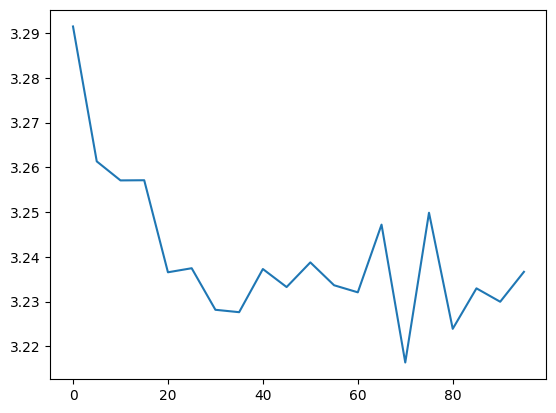

In [ ]:
plt.plot(n_embed,loss_list)
plt.show()

#### embedding dimention of 70 seems to give a very low dev set loss.


In [ ]:
nneurons = range(500,1000,5)
loss_list = []
for n in nneurons:
    g = torch.Generator(device=device).manual_seed(2147483647)
    C = torch.randn((27,70),generator=g,device=device)
    W1 = torch.randn((70*3,n),generator=g,device=device)*0.2
    b1 = torch.randn(n,generator=g,device=device)*0.01
    W2 = torch.randn((n,27),generator=g,device=device)*0.01
    b2 = torch.randn(27,generator=g,device=device) *0
    parameters = [C,W1,b1,W2,b2]
    for p in parameters:
        p.requires_grad = True
    for i in range(10000):
        ix = torch.randint(0,Xtr.shape[0],(32,))
        emb=C[Xtr[ix]]
        h = torch.tanh(emb.view(emb.shape[0],-1)@W1 + b1)
        logits = h@W2+b2
        loss = F.cross_entropy(logits,Ytr[ix])
        ##forward pass
        for p in parameters:
            p.grad = None
        loss.backward()
        for p in parameters:
            p.data += -0.00001*p.grad
    embdev=C[Xdev]
    hdev = torch.tanh(embdev.view(embdev.shape[0],-1)@W1 + b1)
    logitsdev = hdev@W2+b2
    lossdev = F.cross_entropy(logitsdev,Ydev)
    lossdev
    loss_list.append(lossdev.item())

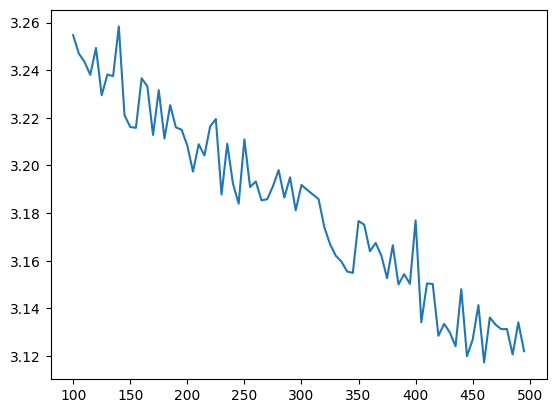

In [ ]:
plt.plot(nneurons,loss_list)
plt.show()

In [ ]:
device

device(type='cpu')

as the neurons increase, the loss seems to decrease with the same amount of compute. neurons more than 500 seems to be very costly. I'll put it 450.


In [ ]:
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27,20),generator=g,device=device)
W1 = torch.randn((20*3,200),generator=g,device=device)*0.1
b1 = torch.randn(200,generator=g,device=device)*0.1
W2 = torch.randn((200,27),generator=g,device=device)*0.01
b2 = torch.randn(27,generator=g,device=device) *0
parameters = [C,W1,b1,W2,b2]

In [ ]:
for p in parameters:
    p.requires_grad = True
for i in range(1000000):
    ix = torch.randint(0,X.shape[0],(50,))
    emb=C[X[ix]]
    h = torch.tanh(emb.view(emb.shape[0],-1)@W1 + b1)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,Y[ix])
    ##forward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.0001*p.grad
loss.item()

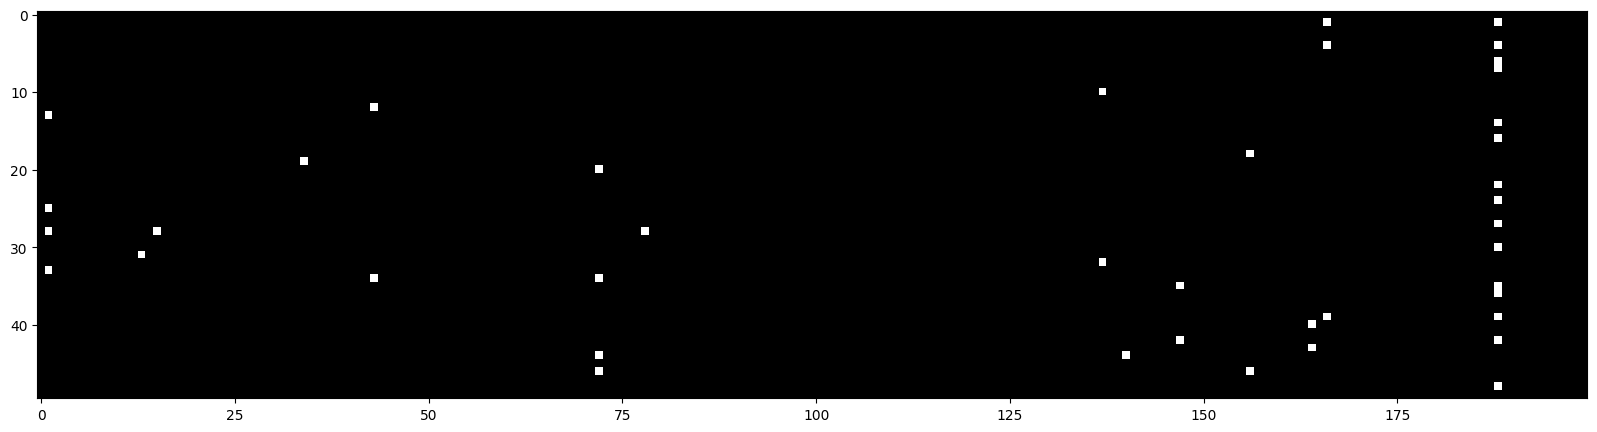

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99 , cmap='gray', interpolation='nearest')

In [ ]:
loss

tensor(2.1369, grad_fn=<NllLossBackward0>)

In [ ]:
emb=C[X]
h = torch.tanh(emb.view(emb.shape[0],-1)@W1 + b1)
logits = h@W2+b2
loss = F.cross_entropy(logits,Y)
loss

tensor(2.2990, grad_fn=<NllLossBackward0>)

In [ ]:
logits

tensor([[-3.3113,  1.7749,  0.5427,  ..., -1.7074, -0.4834,  0.1827],
        [-1.2016,  1.1971, -0.1816,  ..., -1.1713,  1.0333,  0.0584],
        [-0.5148,  2.9257, -0.5128,  ..., -1.6841,  1.2457, -0.4289],
        ...,
        [ 3.5933,  3.7533, -0.6155,  ..., -1.8006,  0.8440, -1.1805],
        [ 3.0390,  3.2507, -1.1667,  ..., -1.4655,  1.4982, -1.1641],
        [ 2.4718,  2.7327, -0.1465,  ..., -0.7867,  0.8967, -0.9939]],
       grad_fn=<AddBackward0>)

In [ ]:
from torch.nn.functional import one_hot
import torch
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    context = [0]*3
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1)@W1 + b1)
        logits = h@W2+b2
        probs = F.softmax(logits,dim=1)
        j = torch.multinomial(probs,num_samples = 1,generator=g).item()
        out.append(j)
        context = context[1:]+[j]
        if j == 0:
            print("".join(itos[i] for i in out))
            break

cexze.
momanuraila.
kayha.
konimitta.
nra.
adk.
kanda.
samiyaullansi.
goton.
moriellano.
ketted.
jen.
emia.
sade.
enkaviyn.
ratls.
mhini.
gavtahlas.
kasdr.
breenl.


In [ ]:
out

[2, 18, 5, 5, 14, 12, 0]